In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [ ]:
df = pd.read_csv("diabetes.csv")

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
invalid_columns = [
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI"
]

print("Zero values:")
print(df[invalid_columns].eq(0).sum())

Zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [ ]:
df[invalid_columns] = df[invalid_columns].replace(0, np.nan)

print("Missing values after replacement:")
print(df.isnull().sum())

Missing values after replacement:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
for column in invalid_columns:
    df[column] = df[column].fillna(df[column].median())

print("Missing values after imputation:")
print(df.isnull().sum())

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [ ]:
# Selecting features for clustering
features = [
    "Pregnancies",
    "Glucose",
    "BloodPressure",
    "SkinThickness",
    "Insulin",
    "BMI",
    "DiabetesPedigreeFunction",
    "Age"
]

X = df[features]

print("Selected Features:")
print(X.head())

Selected Features:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6    148.0           72.0           35.0    125.0  33.6   
1            1     85.0           66.0           29.0    125.0  26.6   
2            8    183.0           64.0           29.0    125.0  23.3   
3            1     89.0           66.0           23.0     94.0  28.1   
4            0    137.0           40.0           35.0    168.0  43.1   

   DiabetesPedigreeFunction  Age  
0                     0.627   50  
1                     0.351   31  
2                     0.672   32  
3                     0.167   21  
4                     2.288   33  


In [ ]:
# Standardize the data
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled Data:")
print(X_scaled[:5])

Scaled Data:
[[ 0.63994726  0.86604475 -0.03198993  0.67064253 -0.18154124  0.16661938
   0.46849198  1.4259954 ]
 [-0.84488505 -1.20506583 -0.5283186  -0.01230129 -0.18154124 -0.85219976
  -0.36506078 -0.19067191]
 [ 1.23388019  2.01666174 -0.69376149 -0.01230129 -0.18154124 -1.33250021
   0.60439732 -0.10558415]
 [-0.84488505 -1.07356674 -0.5283186  -0.69524511 -0.54064177 -0.63388137
  -0.92076261 -1.04154944]
 [-1.14185152  0.50442227 -2.67907616  0.67064253  0.31656594  1.5493025
   5.4849091  -0.0204964 ]]


In [ ]:
# Elbow method
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

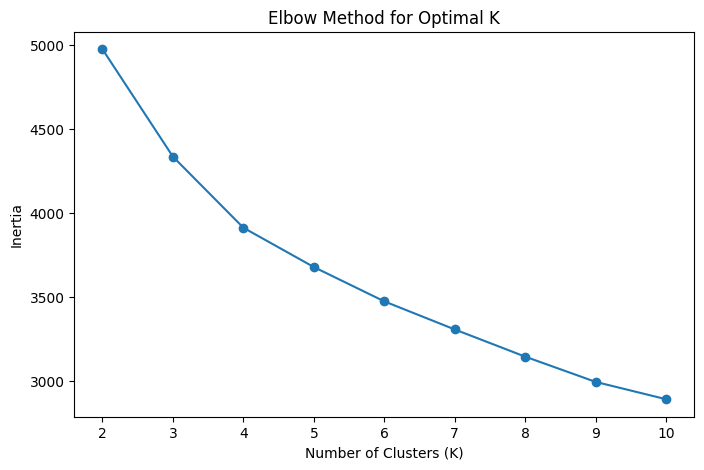

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(range(2, 11), inertia, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")

plt.show()

In [ ]:
# k-means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

df["Cluster"] = clusters

print(df[["Glucose", "BMI", "Age", "Outcome", "Cluster"]].head(10))

   Glucose   BMI  Age  Outcome  Cluster
0    148.0  33.6   50        1        0
1     85.0  26.6   31        0        1
2    183.0  23.3   32        1        0
3     89.0  28.1   21        0        1
4    137.0  43.1   33        1        2
5    116.0  25.6   30        0        1
6     78.0  31.0   26        1        1
7    115.0  35.3   29        0        0
8    197.0  30.5   53        1        2
9    125.0  32.3   54        1        0


In [ ]:
#Evaluate using silhouette Score
silhouette = silhouette_score(X_scaled, clusters)

print("Silhouette Score:", silhouette)

Silhouette Score: 0.19500407738247363


In [ ]:
# Compare different K- values using Silhouette score
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

print(silhouette_scores)

[np.float64(0.19627861483317974), np.float64(0.19500407738247363), np.float64(0.18979077032947686), np.float64(0.17745305895865027), np.float64(0.16816982746206624), np.float64(0.12256077823302804), np.float64(0.14631185790926513), np.float64(0.14662635173937452), np.float64(0.1448140925656229)]


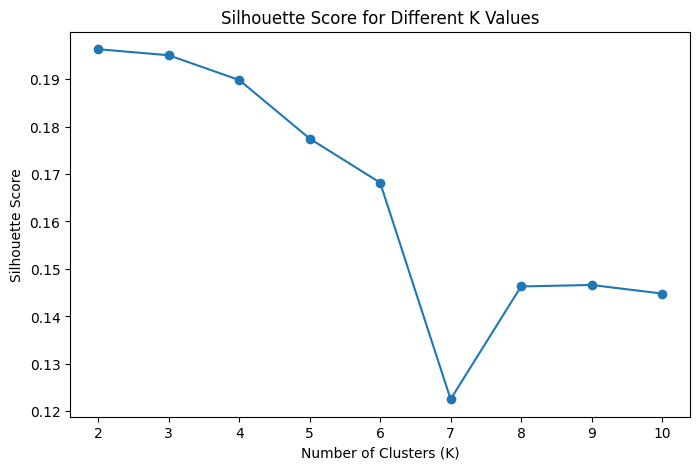

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    silhouette_scores,
    marker='o'
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [ ]:
# Apply PCA
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("PCA Shape:", X_pca.shape)

print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

print("Total Explained Variance:",
      pca.explained_variance_ratio_.sum())

PCA Shape: (768, 2)
Explained Variance Ratio:
[0.28537316 0.18694722]
Total Explained Variance: 0.4723203741075307


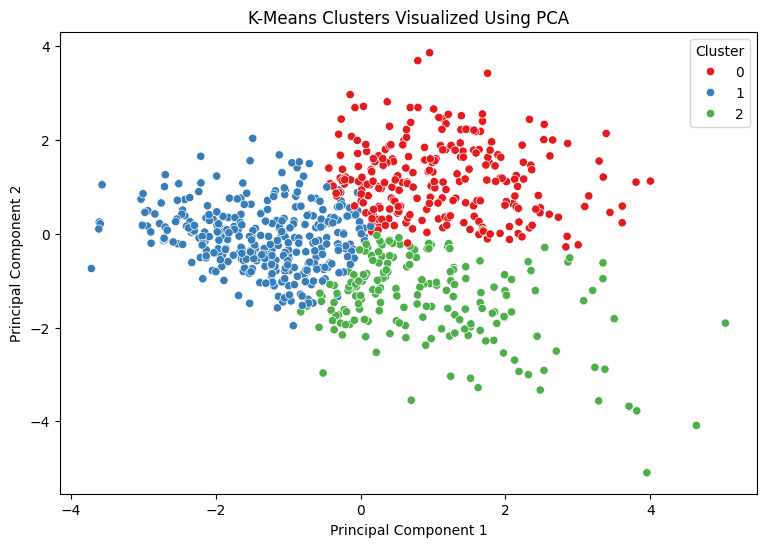

In [ ]:
# Visualise PCA and Clusters
plt.figure(figsize=(9, 6))

sns.scatterplot(
    x=X_pca[:, 0],
    y=X_pca[:, 1],
    hue=df["Cluster"],
    palette="Set1"
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("K-Means Clusters Visualized Using PCA")

plt.show()

In [ ]:
# Compare clusters with diabetes outcome
cluster_outcome = pd.crosstab(
    df["Cluster"],
    df["Outcome"]
)

print(cluster_outcome)
cluster_percentage = pd.crosstab(
    df["Cluster"],
    df["Outcome"],
    normalize="index"
) * 100

print(cluster_percentage)



Outcome    0    1
Cluster          
0        120  128
1        291   44
2         89   96
Outcome          0          1
Cluster                      
0        48.387097  51.612903
1        86.865672  13.134328
2        48.108108  51.891892


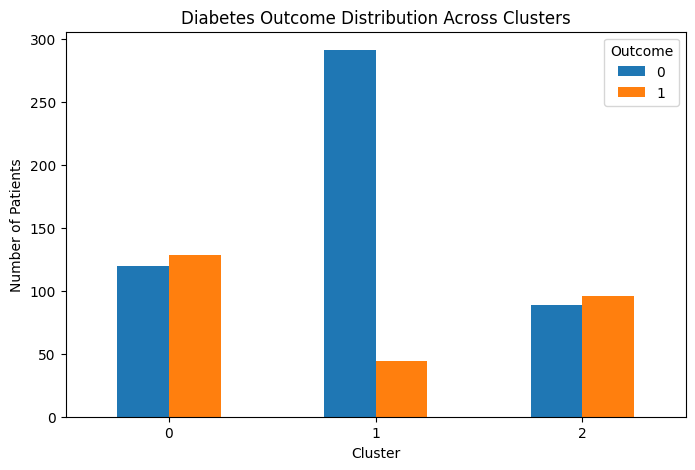

In [ ]:
# Visualize cluster vs outcome
cluster_outcome.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.xlabel("Cluster")
plt.ylabel("Number of Patients")
plt.title("Diabetes Outcome Distribution Across Clusters")

plt.xticks(rotation=0)

plt.show()

In [ ]:
#Analyse cluster characteristics:
cluster_summary = df.groupby("Cluster")[features].mean()

print(cluster_summary)
cluster_summary = df.groupby("Cluster")[
    features + ["Outcome"]
].mean()

print(cluster_summary)

         Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
Cluster                                                                      
0           7.370968  130.790323      78.415323      30.020161  139.633065   
1           2.280597  106.620896      66.764179      24.205970  113.331343   
2           1.951351  136.637838      74.486486      36.762162  191.572973   

               BMI  DiabetesPedigreeFunction        Age  
Cluster                                                  
0        32.808871                  0.456851  46.040323  
1        28.498806                  0.411361  25.943284  
2        39.145405                  0.601600  29.297297  
         Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
Cluster                                                                      
0           7.370968  130.790323      78.415323      30.020161  139.633065   
1           2.280597  106.620896      66.764179      24.205970  113.331343   
2      